In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import io
image_path = 'D:\\E0323036-SEM6\\dl_med\\ultrasound.jfif'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if image is None or image.size == 0:
    print("Error")
else:
    normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    print("✓ Normalization complete")
    denoised = cv2.medianBlur(normalized, 5)
    print("✓ Denoising complete")
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    print("✓ Contrast enhancement complete")
    edges = cv2.Canny(enhanced, 50, 150)
    print("✓ Edge detection complete")
    _, segmented = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print("✓ Segmentation complete")

✓ Normalization complete
✓ Denoising complete
✓ Contrast enhancement complete
✓ Edge detection complete
✓ Segmentation complete


In [7]:
    mean_intensity = np.mean(enhanced)
    std_intensity = np.std(enhanced)
    anechoic_threshold = mean_intensity - std_intensity
    hyperechoic_threshold = mean_intensity + std_intensity
    anechoic = np.sum(enhanced < anechoic_threshold)
    hypoechoic = np.sum((enhanced >= anechoic_threshold) & (enhanced < mean_intensity))
    isoechoic = np.sum((enhanced >= mean_intensity) & (enhanced < hyperechoic_threshold))
    hyperechoic = np.sum(enhanced >= hyperechoic_threshold)
    total = enhanced.size

In [15]:

    print(f"\nn1. ANECHOIC (Black – Fluid/Cysts):")
    print(f"  {anechoic:,} pixels ({anechoic/total*100:.1f}%)")
    print(f"\nn2. HYPOECHOIC (Dark Gray – Muscles/Masses):")
    print(f"  {hypoechoic:,} pixels ({hypoechoic/total*100:.1f}%)")
    print(f"\nn3. ISOECHOIC (Gray – Normal Tissue):")
    print(f"  {isoechoic:,} pixels ({isoechoic/total*100:.1f}%)")
    print(f"\nn4. HYPERECHOIC (Bright – Bones/Calcifications):")
    print(f"  {hyperechoic:,} pixels ({hyperechoic/total*100:.1f}%)")
    fig = plt.figure(figsize=(16, 12))



n1. ANECHOIC (Black – Fluid/Cysts):
  0 pixels (0.0%)

n2. HYPOECHOIC (Dark Gray – Muscles/Masses):
  30,803 pixels (60.8%)

n3. ISOECHOIC (Gray – Normal Tissue):
  10,724 pixels (21.2%)

n4. HYPERECHOIC (Bright – Bones/Calcifications):
  9,098 pixels (18.0%)


<Figure size 1600x1200 with 0 Axes>

✓ Normalization complete
✓ Denoising complete
✓ Contrast enhancement complete
✓ Edge detection complete
✓ Segmentation complete

n1. ANECHOIC (Black – Fluid/Cysts):
  0 pixels (0.0%)

n2. HYPOECHOIC (Dark Gray – Muscles/Masses):
  30,803 pixels (60.8%)

n3. ISOECHOIC (Gray – Normal Tissue):
  10,724 pixels (21.2%)

n4. HYPERECHOIC (Bright – Bones/Calcifications):
  9,098 pixels (18.0%)


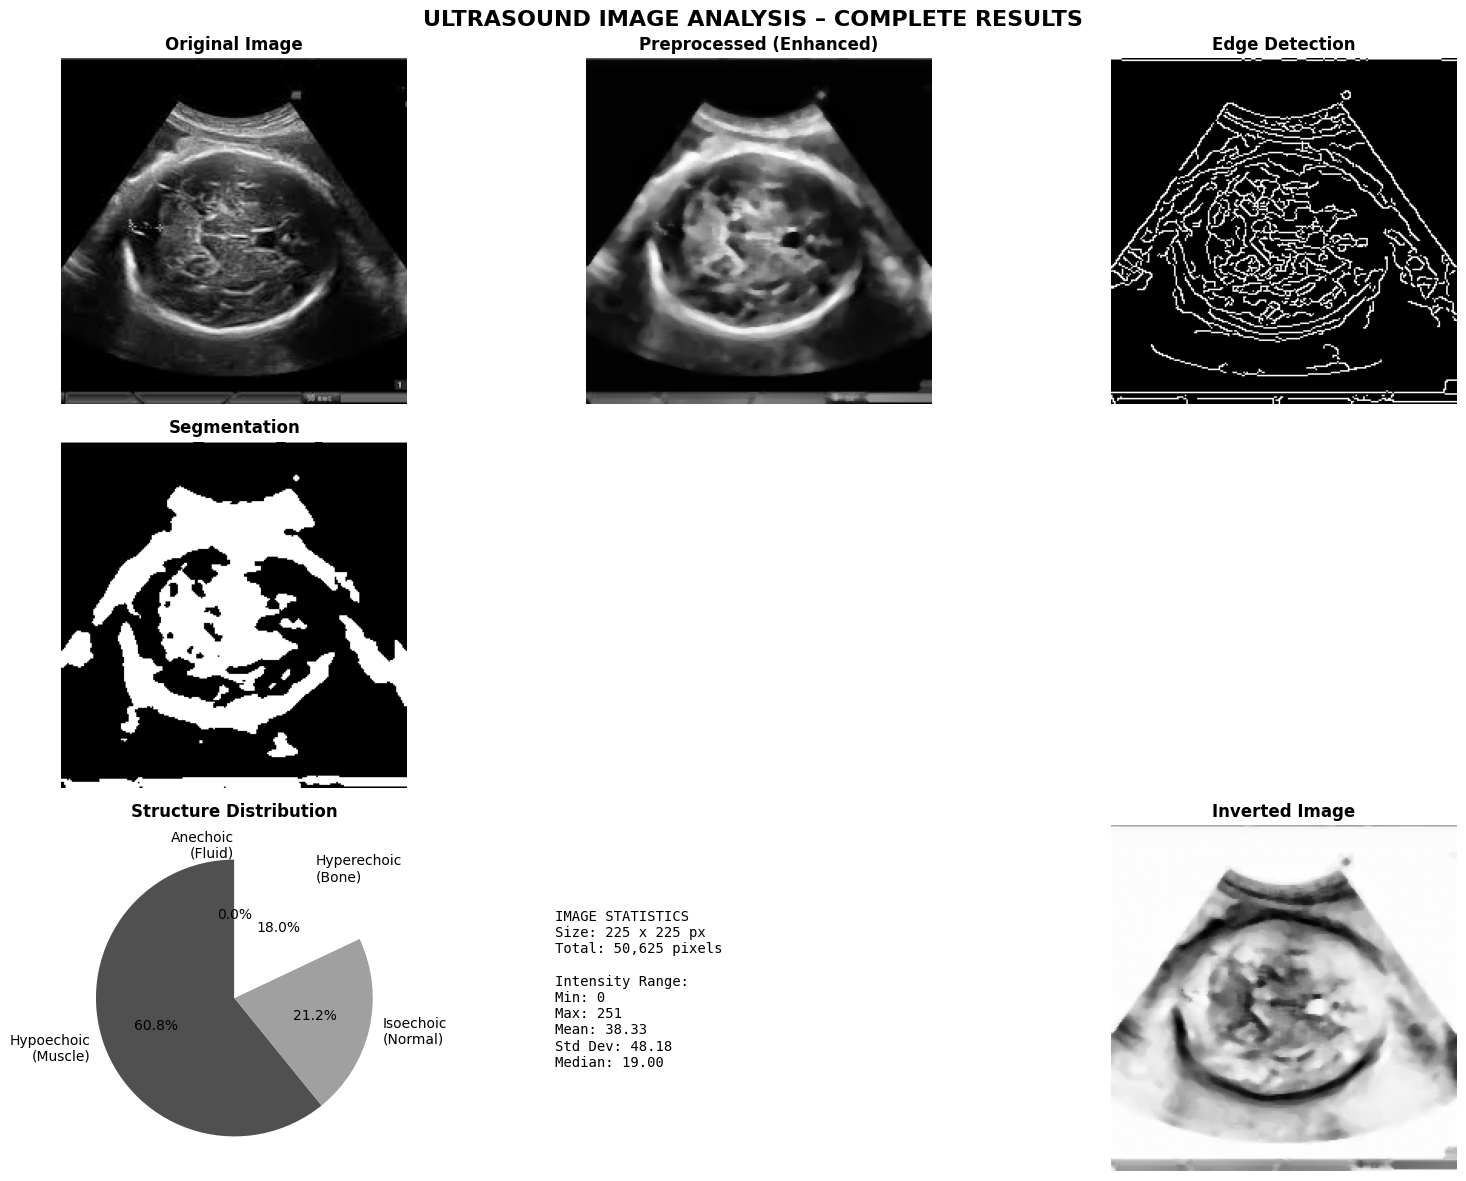

✓ Main visualization complete


In [4]:
# Import Necessary Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import io

# Load the image
image_path = 'D:\\E0323036-SEM6\\dl_med\\ultrasound.jfif'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Preprocessing
# Add a check to ensure image is loaded correctly
if image is None or image.size == 0:
    print("Error: The input 'image' is empty. Please ensure the image file exists and is loaded correctly in the previous cell.")
else:
    # Normalize
    normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    print("✓ Normalization complete")

    # Denoise (remove speckle)
    denoised = cv2.medianBlur(normalized, 5)
    print("✓ Denoising complete")

    # Enhance contrast (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    print("✓ Contrast enhancement complete")

    # Edge detection
    edges = cv2.Canny(enhanced, 50, 150)
    print("✓ Edge detection complete")

    # Segmentation
    _, segmented = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print("✓ Segmentation complete")

    # Structure Visualization
    mean_intensity = np.mean(enhanced)
    std_intensity = np.std(enhanced)

    # Define thresholds based on echogenicity
    anechoic_threshold = mean_intensity - std_intensity
    hyperechoic_threshold = mean_intensity + std_intensity

    # Count pixels in each category
    anechoic = np.sum(enhanced < anechoic_threshold)
    hypoechoic = np.sum((enhanced >= anechoic_threshold) & (enhanced < mean_intensity))
    isoechoic = np.sum((enhanced >= mean_intensity) & (enhanced < hyperechoic_threshold))
    hyperechoic = np.sum(enhanced >= hyperechoic_threshold)
    total = enhanced.size

    print(f"\nn1. ANECHOIC (Black – Fluid/Cysts):")
    print(f"  {anechoic:,} pixels ({anechoic/total*100:.1f}%)")
    print(f"\nn2. HYPOECHOIC (Dark Gray – Muscles/Masses):")
    print(f"  {hypoechoic:,} pixels ({hypoechoic/total*100:.1f}%)")
    print(f"\nn3. ISOECHOIC (Gray – Normal Tissue):")
    print(f"  {isoechoic:,} pixels ({isoechoic/total*100:.1f}%)")
    print(f"\nn4. HYPERECHOIC (Bright – Bones/Calcifications):")
    print(f"  {hyperechoic:,} pixels ({hyperechoic/total*100:.1f}%)")

    # Create main analysis figure
    fig = plt.figure(figsize=(16, 12))

    # Original Image
    plt.subplot(3, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image', fontsize=12, fontweight='bold')
    plt.axis('off')

    # Preprocessed (Enhanced)
    plt.subplot(3, 3, 2)
    plt.imshow(enhanced, cmap='gray')
    plt.title('Preprocessed (Enhanced)', fontsize=12, fontweight='bold')
    plt.axis('off')

    # Edge Detection
    plt.subplot(3, 3, 3)
    plt.imshow(edges, cmap='gray')
    plt.title('Edge Detection', fontsize=12, fontweight='bold')
    plt.axis('off')

    # Segmentation
    plt.subplot(3, 3, 4)
    plt.imshow(segmented, cmap='gray')
    plt.title('Segmentation', fontsize=12, fontweight='bold')
    plt.axis('off')

    # Structure Distribution Pie Chart
    plt.subplot(3, 3, 7)
    labels = ['Anechoic\n(Fluid)', 'Hypoechoic\n(Muscle)', 'Isoechoic\n(Normal)', 'Hyperechoic\n(Bone)']
    sizes = [anechoic/total*100, hypoechoic/total*100, isoechoic/total*100, hyperechoic/total*100]
    colors = ['#000000', '#505050', '#A0A0A0', '#FFFFFF']
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title('Structure Distribution', fontsize=12, fontweight='bold')

    # Image Statistics
    plt.subplot(3, 3, 8)
    stats_text = f"""IMAGE STATISTICS
Size: {image.shape[1]} x {image.shape[0]} px
Total: {image.size:,} pixels

Intensity Range:
Min: {image.min()}
Max: {image.max()}
Mean: {image.mean():.2f}
Std Dev: {image.std():.2f}
Median: {np.median(image):.2f}
"""
    plt.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
             verticalalignment='center', transform=plt.gca().transAxes)
    plt.axis('off')

    # Inverted Image
    plt.subplot(3, 3, 9)
    plt.imshow(255 - enhanced, cmap='gray')
    plt.title('Inverted Image', fontsize=12, fontweight='bold')
    plt.axis('off')

    plt.suptitle('ULTRASOUND IMAGE ANALYSIS – COMPLETE RESULTS', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

    print("✓ Main visualization complete")